# Sales Forecasting - Data Processing Pipeline

This notebook builds the data processing pipeline for time series forecasting.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys

# Add src to path
sys.path.insert(0, str(Path('..').resolve()))

from src.data_processing import (
    load_excel_data,
    filter_valid_transactions,
    add_sales_column,
    aggregate_daily_sales,
)
from src.feature_engineering import create_forecast_features
from src.validation import run_all_validations, print_validation_report

# Set style
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')

# Screenshot settings
SCREENSHOTS_DIR = Path('../reports/screenshots')
SCREENSHOTS_DIR.mkdir(parents=True, exist_ok=True)

def save_screenshot(fig, name):
    """Save figure to screenshots directory."""
    filepath = SCREENSHOTS_DIR / f'{name}.png'
    fig.savefig(filepath, dpi=150, bbox_inches='tight')
    print(f'Saved: {filepath}')

## 1. Load and Clean Raw Data

In [7]:
# Load raw data
raw_path = Path('../data/raw/Online Retail.xlsx')
df_raw = load_excel_data(raw_path)
print(f"Raw data shape: {df_raw.shape}")

# Clean data
df_clean = filter_valid_transactions(df_raw)
df_clean = add_sales_column(df_clean)
print(f"Cleaned data shape: {df_clean.shape}")

Raw data shape: (541909, 8)
Cleaned data shape: (397884, 9)


## 2. Aggregate Daily Sales

In [8]:
# Aggregate by date
daily_sales = aggregate_daily_sales(df_clean)
print(f"Daily sales shape: {daily_sales.shape}")
print(f"Date range: {daily_sales['Date'].min()} to {daily_sales['Date'].max()}")
daily_sales.head()

Daily sales shape: (305, 5)
Date range: 2010-12-01 00:00:00 to 2011-12-09 00:00:00


,Date,total_sales,transaction_count,quantity_sold,unique_customers
0,2010-12-01,46376.49,121,24215,95
1,2010-12-02,47316.53,137,31142,99
2,2010-12-03,23921.71,57,11839,50
3,2010-12-05,31771.60,87,16449,75
4,2010-12-06,31215.64,94,16291,82


## 3. Validate Data Quality

In [9]:
# Run validations
results = run_all_validations(daily_sales)
print_validation_report(results)


DATA VALIDATION REPORT

✗ FAIL: No Gaps > 7 Days
  Found 1 gaps larger than 7 days
  gap_count: 1
  max_gap: 12
  missing_dates_total: 69

✓ PASS: Dates Monotonic
  Dates are in order

✓ PASS: No Duplicates
  No duplicates

✓ PASS: Minimum Records
  Sufficient records: 305

✗ SOME CHECKS FAILED - Review issues above



## 4. Add Time-Based Features

In [10]:
# Create forecast features
df_features = create_forecast_features(
    daily_sales,
    date_column='Date',
    target_column='total_sales',
    lags=[1, 7, 14, 28],
    windows=[7, 14, 28]
)

print(f"Features shape: {df_features.shape}")
print(f"\nColumns: {list(df_features.columns)}")
df_features.head()

Features shape: (305, 27)

Columns: ['Date', 'total_sales', 'transaction_count', 'quantity_sold', 'unique_customers', 'year', 'month', 'day', 'day_of_week', 'day_of_year', 'week_of_year', 'quarter', 'is_weekend', 'month_name', 'day_name', 'total_sales_lag_1', 'total_sales_lag_7', 'total_sales_lag_14', 'total_sales_lag_28', 'total_sales_rolling_mean_7', 'total_sales_rolling_std_7', 'total_sales_rolling_mean_14', 'total_sales_rolling_std_14', 'total_sales_rolling_mean_28', 'total_sales_rolling_std_28', 'total_sales_expanding_mean', 'total_sales_expanding_std']


,Date,total_sales,transaction_count,quantity_sold,unique_customers,year,month,day,day_of_week,day_of_year,...,total_sales_lag_14,total_sales_lag_28,total_sales_rolling_mean_7,total_sales_rolling_std_7,total_sales_rolling_mean_14,total_sales_rolling_std_14,total_sales_rolling_mean_28,total_sales_rolling_std_28,total_sales_expanding_mean,total_sales_expanding_std
0,2010-12-01,46376.49,121,24215,95,2010,12,1,2,335,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,46376.4900,NaN
1,2010-12-02,47316.53,137,31142,99,2010,12,2,3,336,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,46846.5100,664.708659
2,2010-12-03,23921.71,57,11839,50,2010,12,3,4,337,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,39204.9100,13243.982425
3,2010-12-05,31771.60,87,16449,75,2010,12,5,6,339,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,37346.5825,11434.548732
4,2010-12-06,31215.64,94,16291,82,2010,12,6,0,340,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,36120.3940,10275.182223


## 5. Visualize Features

Saved: ../reports/screenshots/02_daily_sales_features.png


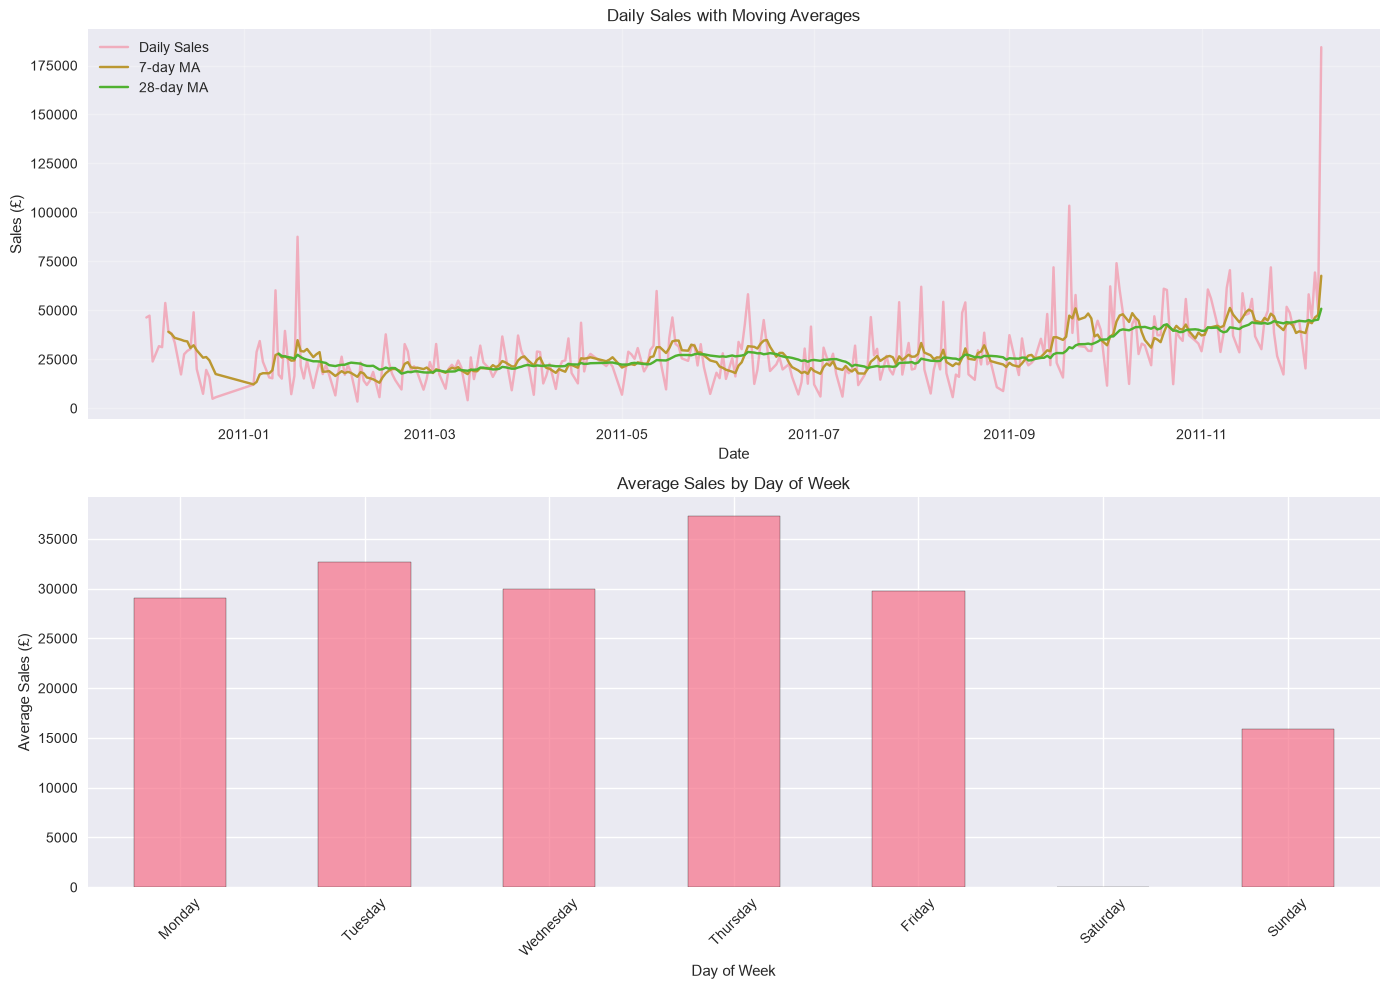

In [11]:
# Plot daily sales with rolling averages
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Daily sales
axes[0].plot(df_features['Date'], df_features['total_sales'], alpha=0.5, label='Daily Sales')
axes[0].plot(df_features['Date'], df_features['total_sales_rolling_mean_7'], label='7-day MA')
axes[0].plot(df_features['Date'], df_features['total_sales_rolling_mean_28'], label='28-day MA')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Sales (£)')
axes[0].set_title('Daily Sales with Moving Averages')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Sales by day of week
dow_sales = df_features.groupby('day_name')['total_sales'].mean()
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_sales = dow_sales.reindex(dow_order)
dow_sales.plot(kind='bar', ax=axes[1], edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Average Sales (£)')
axes[1].set_title('Average Sales by Day of Week')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
save_screenshot(fig, '02_daily_sales_features')
plt.show()

## 6. Save Processed Data

In [12]:
# Save processed data
output_path = Path('../data/processed/daily_sales_features.csv')
df_features.to_csv(output_path, index=False)
print(f"Saved processed data to: {output_path}")
print(f"Shape: {df_features.shape}")

Saved processed data to: ../data/processed/daily_sales_features.csv
Shape: (305, 27)


In [13]:
# Summary statistics
print("="*60)
print("DATA PROCESSING SUMMARY")
print("="*60)
print(f"Input records: {df_raw.shape[0]:,}")
print(f"After cleaning: {df_clean.shape[0]:,}")
print(f"Daily aggregations: {daily_sales.shape[0]:,}")
print(f"Final features: {df_features.shape[1]}")
print(f"Date range: {daily_sales['Date'].min().date()} to {daily_sales['Date'].max().date()}")
print(f"Total sales: £{daily_sales['total_sales'].sum():,.2f}")
print("="*60)

DATA PROCESSING SUMMARY
Input records: 541,909
After cleaning: 397,884
Daily aggregations: 305
Final features: 27
Date range: 2010-12-01 to 2011-12-09
Total sales: £8,911,407.90
